## Лабораторная работа №2
Выполнил: **Ефименко Кирилл М8О-309Б-22**

In [58]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.0 MB/s eta 0:00:00


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

In [4]:
df = pd.read_csv('/content/train.csv')
df

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11012,2010-07-10,57.0,300000.0,850.0,14756.0,48.0,Married,2.0,Own,620.0,...,Employed,Associate,38.0,167544.0,0.094756,0.106387,378.792448,0.039952,1.0,32.440586
11013,2003-10-22,28.0,15000.0,300.0,51361.0,96.0,Single,1.0,Own,696.0,...,Employed,Bachelor,5.0,116879.0,0.446361,0.401087,1793.042130,1.991234,0.0,67.673170
11014,1983-05-12,23.0,15000.0,302.0,30724.0,72.0,Married,3.0,Rent,413.0,...,Self-Employed,Associate,0.0,250778.0,0.404724,0.360670,1047.672294,1.168538,0.0,75.292707
11015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Удалим категориальные переменные

In [7]:
cat_columns = df.select_dtypes(['object']).columns.to_list()

In [8]:
df.drop(cat_columns, axis=1, inplace=True)

Удалим пропуски

In [11]:
df.dropna(axis=0, inplace=True)

Преобразуем таргет к типу int

In [17]:
df['LoanApproved'] = df['LoanApproved'].astype(int)

In [18]:
df.dtypes

,0
Age,float64
AnnualIncome,float64
CreditScore,float64
LoanAmount,float64
LoanDuration,float64
NumberOfDependents,float64
MonthlyDebtPayments,float64
CreditCardUtilizationRate,float64
NumberOfOpenCreditLines,float64
NumberOfCreditInquiries,float64


Удалим выбросы

In [21]:
q03, q97 = df['RiskScore'].quantile(q=0.03), df['RiskScore'].quantile(q=0.97)

In [22]:
df = df[df['RiskScore'] > q03]
df = df[df['RiskScore'] < q97]

Реализуем класс логистической регрессии

In [23]:
import numpy as np

class LogReg:
    def __init__(self, learning_rate=0.01, max_iter=1000, tol=1e-6):
        """
        :param learning_rate: Шаг обучения для градиентного спуска
        :param max_iter: Максимальное количество итераций
        :param tol: Допустимая погрешность изменения функции потерь для остановки
        """
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, train_data, train_target):
        """
        Обучение модели методом градиентного спуска.
        :param train_data: Матрица обучающих данных, размер (n_samples, n_features)
        :param train_target: Целевые значения, размер (n_samples,)
        """
        n_samples, n_features = train_data.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.max_iter):
            linear_model = np.dot(train_data, self.weights) + self.bias
            predictions = self.sigmoid(linear_model)

            errors = predictions - train_target
            gradient_weights = np.dot(train_data.T, errors) / n_samples
            gradient_bias = np.mean(errors)

            self.weights -= self.learning_rate * gradient_weights
            self.bias -= self.learning_rate * gradient_bias

            loss = -np.mean(train_target * np.log(predictions + 1e-9) + \
                            (1 - train_target) * np.log(1 - predictions + 1e-9))

            if i > 0 and abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

    def predict(self, data):
        """
        Прогнозирование меток для входных данных.
        :param data: Матрица данных, размер (n_samples, n_features)
        :return: Предсказанные метки (0 или 1), размер (n_samples,)
        """
        linear_model = np.dot(data, self.weights) + self.bias
        predictions = self.sigmoid(linear_model)
        return (predictions >= 0.5).astype(int)

Разобьем выборку на тест и трейн

In [39]:
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Выполним предсказания на самописном методе

Accuracy: 0.9792332268370607
Recall:  0.9778247096092925
F1:  0.9793759915388683
Precision:  0.9809322033898306


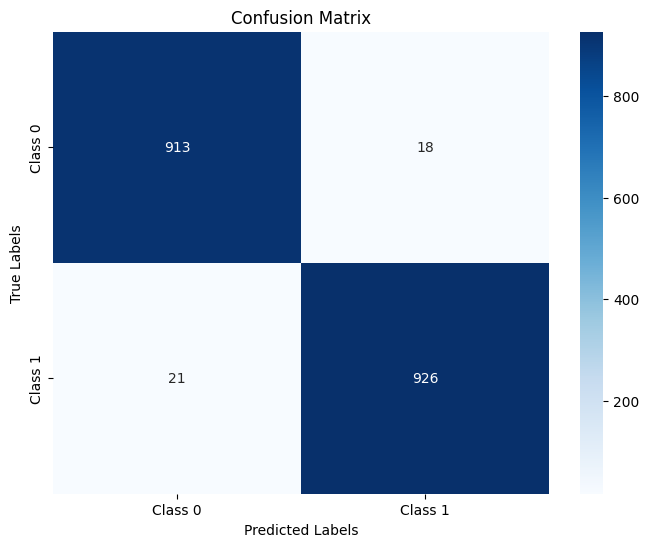

In [41]:
model = LogReg(learning_rate=0.1, max_iter=1000, tol=1e-6)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("Handmade logistic regression!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Предсказания на реализации логистической регрессии из sklearn

Skelarn logistic regression!
Accuracy: 0.9914802981895634
Recall:  0.9926082365364308
F1:  0.9915611814345991
Precision:  0.9905163329820864


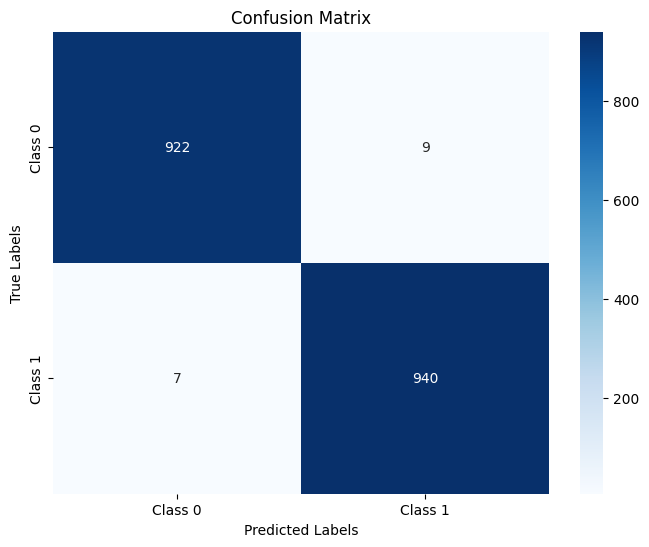

In [43]:
clf = LogisticRegression(max_iter=1000, tol=1e-6).fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("Sklearn logistic regression!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Предсказания SVM sklearn

Skelearn SVM classifier!
Accuracy: 0.9920127795527156
Recall:  0.9915522703273495
F1:  0.9920760697305864
Precision:  0.992600422832981


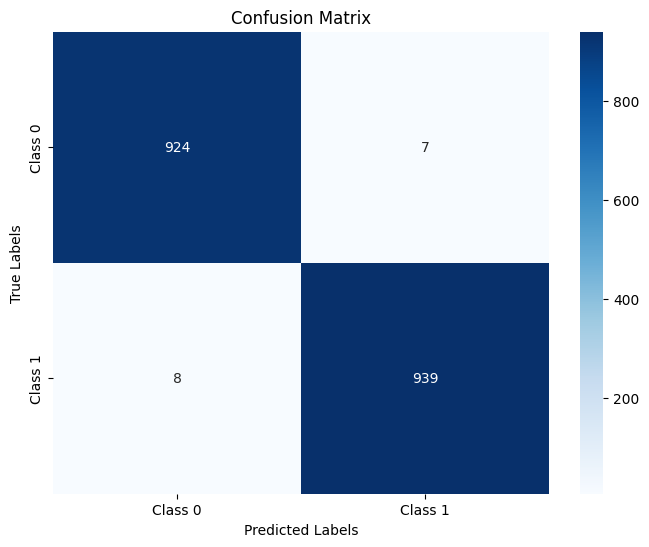

In [46]:
clf = LinearSVC(max_iter=1000, tol=1e-6).fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("Sklearn SVM classifier!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Предсказания решающего дерева sklearn

Skelearn SVM classifier!
Accuracy: 0.9829605963791267
Recall:  0.9831045406546991
F1:  0.9831045406546991
Precision:  0.9831045406546991


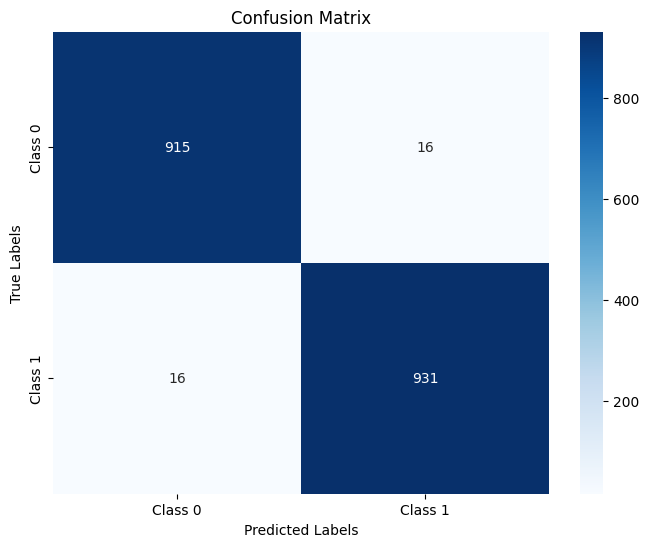

In [49]:
clf = DecisionTreeClassifier().fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("Sklearn SVM classifier!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Предсказания sklearn Random Forest

Sklearn SVM classifier!
Accuracy: 0.9760383386581469
Recall:  0.9778247096092925
F1:  0.9762783342119136
Precision:  0.9747368421052631


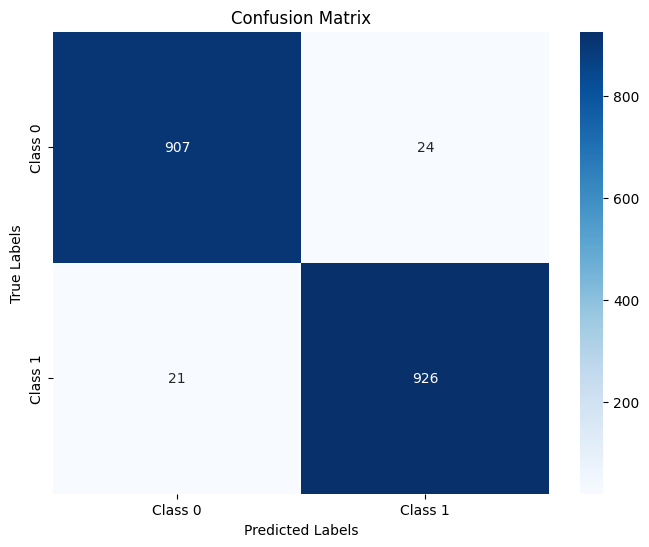

In [52]:
clf = RandomForestClassifier(max_depth=10).fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("Sklearn SVM classifier!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

GBM sklearn

Sklearn GBM classifier!
Accuracy: 0.9877529286474973
Recall:  0.986272439281943
F1:  0.98783712321523
Precision:  0.989406779661017


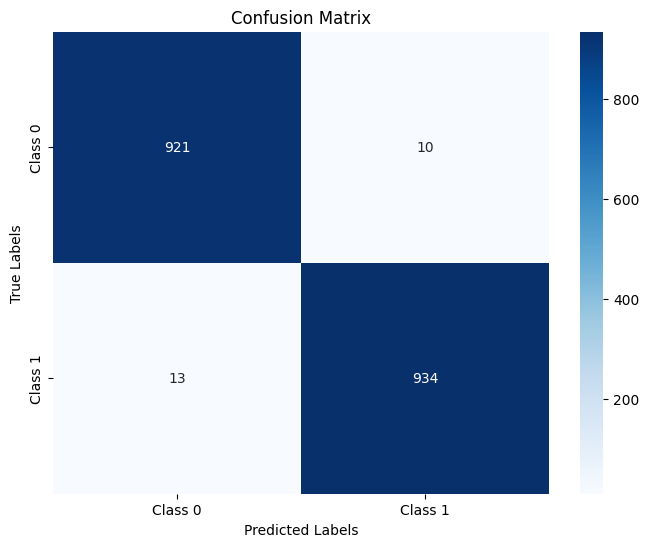

In [57]:
clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3).fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("Sklearn GBM classifier!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Catboost GBM

Sklearn GBM classifier!
Accuracy: 0.9914802981895634
Recall:  0.989440337909187
F1:  0.9915343915343915
Precision:  0.9936373276776246


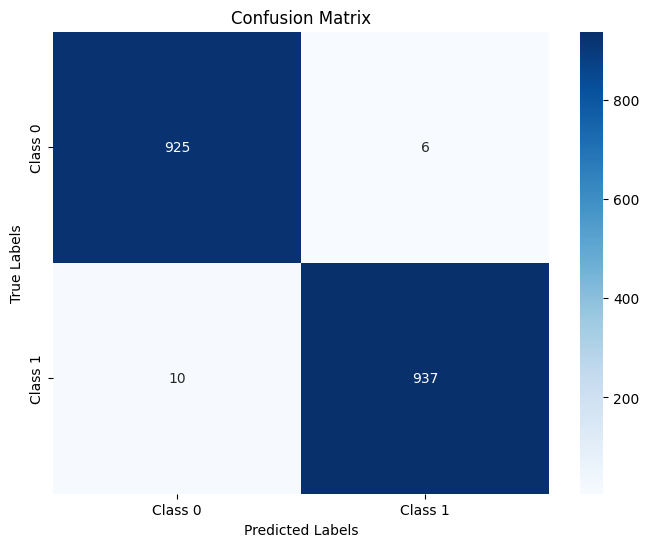

In [62]:
clf = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=3, verbose=0).fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("Catboost GBM classifier!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

Sklearn GBM classifier!
Accuracy: 0.9898828541001065
Recall:  0.9873284054910243
F1:  0.9899417681312864
Precision:  0.9925690021231423


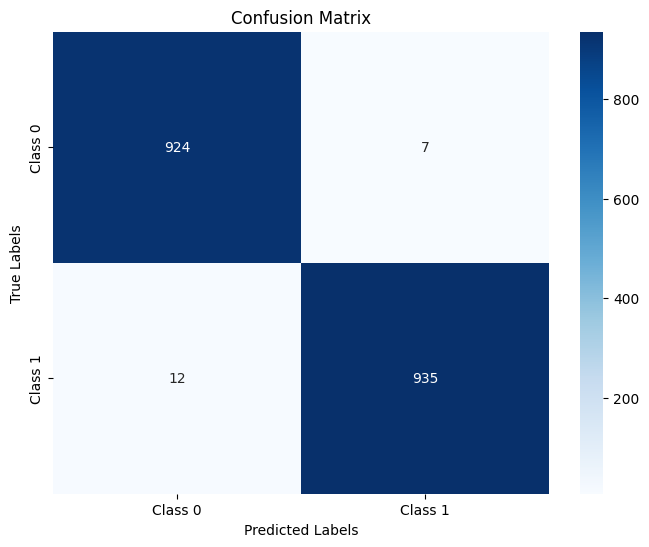

In [67]:
clf = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3).fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("XGB classifier!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

LightGBM предсказания

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LigthGBM classifier!
Accuracy: 0.9898828541001065
Recall:  0.9883843717001056
F1:  0.9899524061343205
Precision:  0.9915254237288136


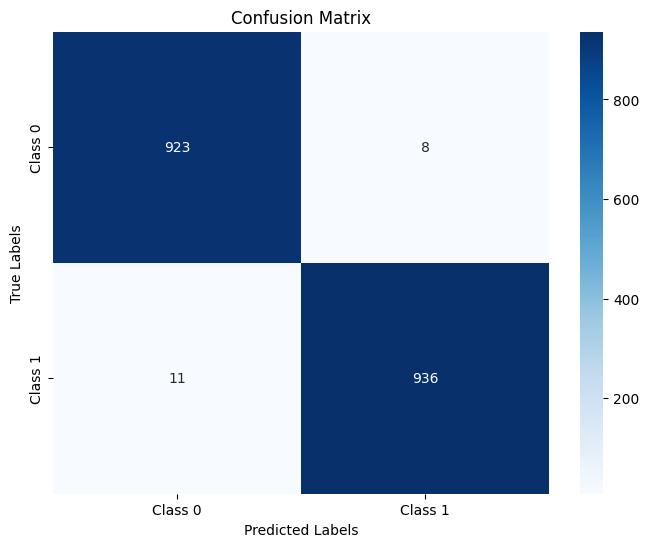

In [71]:
clf = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, verbose=-1).fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("LigthGBM classifier!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## Выводы

1. **Использованные алгоритмы:** В рамках работы были протестированы следующие алгоритмы классификации: `Random Forest`, `Gradient Boosting`, `CatBoost`, `XGBoost` и `LightGBM`. Каждый из них показал свои сильные и слабые стороны в задаче классификации.

2. **Метрики оценки:** Для оценки качества моделей использовались метрики:
   - **Accuracy** – общая точность предсказаний.
   - **Precision** – доля истинно положительных результатов среди всех положительных предсказаний.
   - **Recall** – доля найденных положительных классов среди всех истинно положительных.
   - **F1-Score** – гармоническое среднее между Precision и Recall.

3. **Сравнение алгоритмов:**
   - **CatBoost** и **XGBoost** продемонстрировали лучшие результаты по метрике F1-Score, что говорит об их эффективности в задачах классификации, особенно при наличии несбалансированных данных.
   - **LightGBM** показал высокую точность (Accuracy) и хорошую скорость работы, что делает его подходящим для работы с большими объемами данных.
   - **Gradient Boosting** из sklearn обеспечил сбалансированные метрики, но обучается медленнее, чем LightGBM или XGBoost.
   - **Random Forest** был прост в реализации и показал конкурентные результаты, хотя уступил методам бустинга.

4. **Наиболее информативная метрика:** В задаче классификации наиболее полезной оказалась метрика **F1-Score**, так как она учитывает как точность (Precision), так и полноту (Recall). Это важно для задач с возможным дисбалансом классов.

5. **Матрицы ошибок:** Матрицы ошибок предоставили наглядное представление о работе моделей. Например, XGBoost продемонстрировал высокое значение Recall, что связано с увеличением количества предсказанных положительных классов, включая ложноположительные.

6. **Результаты:**
   - **CatBoost** и **LightGBM** оказались наиболее сбалансированными моделями по качеству предсказаний и скорости обучения.
   - **XGBoost** чуть уступил по скорости, но показал высокую эффективность в предсказаниях.

7. **Рекомендации:**
   - Для задач, включающих категориальные признаки, рекомендуется использовать **CatBoost**, так как он не требует дополнительного кодирования данных.
   - **LightGBM** подходит для обработки больших объемов данных благодаря высокой скорости работы.
   - **Random Forest** можно использовать, если классы сбалансированы, а интерпретируемость модели имеет высокое значение.

Таким образом, выбор алгоритма должен зависеть от специфики данных и требований к задаче. В данной работе **CatBoost** и **LightGBM** показали наилучшие результаты, что делает их наиболее подходящими для большинства задач классификации.



На доп балл предсказание с помощью Наивного Байеса


LigthGBM classifier!
Accuracy: 0.9286474973375932
Recall:  0.9535374868004224
F1:  0.9309278350515464
Precision:  0.9093655589123867


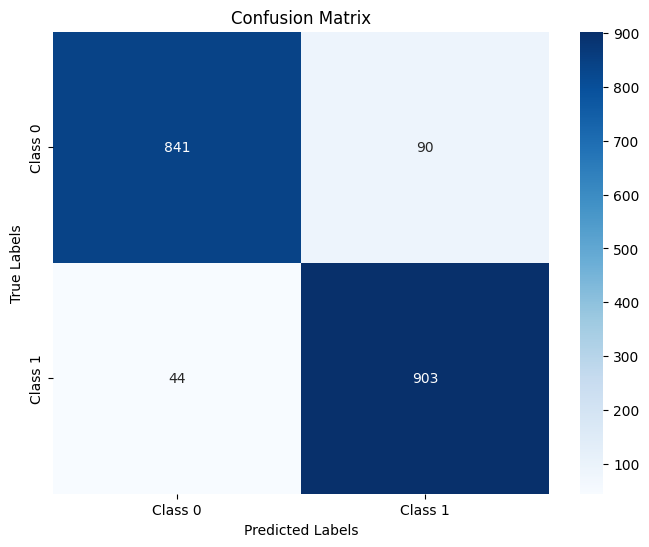

In [74]:
clf = GaussianNB().fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions)

print("Sklearn Naive Bayes classifier!")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Recall: ", recall_score(y_test, predictions))
print("F1: ", f1_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()